#**DESCRIPTIVE ANALYSIS QUESTIONS**

**DESCRIPTIVE ANALYSIS QUESTIONS**
1. Central Tendency and Dispersion

•	What are the mean, median, and standard deviation for numeric columns (e.g., element concentrations)?

•	Are there any columns with highly skewed distributions?

2. Outliers and Anomalies

•	Are there significant outliers in numeric columns (e.g., using boxplots or z-scores)?

•	Do certain samples or elements exhibit unexpected values that may indicate errors or unique conditions?

3. Relationships and Correlations

•	Are there strong correlations between certain element concentrations (e.g., Si and Ca, Sr and Ba)?

•	How do related elements (e.g., rare earth elements like La, Ce, Nd) compare in terms of their distributions?

4. Grouped Analysis

•	How do concentrations vary by categories (if any are provided, e.g., sample groups)?

•	Are there consistent trends or differences across replicate samples?

5. Distributions

•	What are the distribution shapes (e.g., normal, skewed) for each numeric column?

•	Are concentrations normalized to appropriate reference values?

6. Element-Specific Questions

•	Which elements have the highest and lowest concentrations across the dataset? Are there elements with concentrations consistently below detection limits?


# calling the important libraries

In [33]:
# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



importing the google drive and uploading the file

if files are needed to be uploaded from local machines into colab then use

from google.colab import files

uploaded = files.upload()

In [34]:
icpms = pd.read_excel('/content/Combined Datasets EPMA (1).xlsx',
                             sheet_name= 'icpms'
                             )

icpms.describe()
icpms.shape

(418, 41)

In [35]:
icpms =icpms.dropna()

In [36]:
icpms

,SAMPLE,Be,B,Mg,Si,Ca,Sc,Ti,V,Cr,...,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U,T
0,KL2023-07-19-4_1,0.310,2.87,89280.11,220070.69,161599.52,94.13,12726.38,361.77,1795.78,...,2.26,0.261,1.51,0.188,3.74,0.208,0.038,0.096,0.0176,3
1,KL2023-07-19-4_2,0.280,2.93,93192.75,220410.17,160831.94,93.43,10796.43,312.03,2971.39,...,1.56,0.201,1.41,0.184,3.03,0.238,0.054,0.103,0.0157,3
2,KL2023-07-19-4_3,0.155,2.84,97795.37,226428.56,159958.36,93.26,8539.11,257.09,617.36,...,2.08,0.234,1.64,0.225,4.09,0.188,0.060,0.113,0.0135,3
14,KL2023-07-19-4_15,0.570,2.96,87143.91,219999.98,163205.75,76.85,11458.76,340.04,304.66,...,2.40,0.338,1.85,0.277,7.59,0.533,0.253,0.221,0.0462,3
15,KL2023-07-19-4_16,0.120,2.62,99992.08,231377.30,158495.17,98.70,8691.68,259.24,880.77,...,2.43,0.307,1.74,0.290,4.70,0.269,0.093,0.172,0.0274,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,KL2023-07-25-8_20,2.480,2.84,40927.28,187607.67,163210.42,11.56,18708.39,374.07,1.32,...,4.21,0.577,4.01,0.597,13.05,5.180,0.284,0.724,0.0730,2
391,KL2023-07-25-8_21,0.560,2.86,73140.32,201304.09,163643.84,65.48,14949.76,294.55,123.44,...,2.37,0.278,1.83,0.214,5.68,0.594,0.131,0.260,0.0314,2
400,KL2023-07-25-8_30,0.380,2.80,90324.70,215612.05,161709.22,61.58,7423.53,206.42,2340.55,...,1.32,0.164,1.07,0.131,2.46,0.286,0.170,0.256,0.0361,2
401,KL2023-07-25-8_31,0.670,2.67,80453.15,204705.73,161215.83,55.60,13002.61,223.59,174.43,...,2.46,0.312,1.69,0.256,5.45,0.658,0.204,0.389,0.0554,2


In [37]:
icpms.dtypes

,0
SAMPLE,object
Be,float64
B,float64
Mg,float64
Si,float64
Ca,float64
Sc,float64
Ti,float64
V,float64
Cr,float64


In [38]:
icpms['T'] = icpms['T'].astype(float)

In [39]:
laicpms_with_age = icpms

#**Data type checking**

**2. Data Consistency**

Are the sample IDs (SAMPLE column) unique and consistent in format?

Are all numeric values in concentration columns formatted correctly (e.g., no < or > remaining)?

Are duplicate entries present, and if so, do they represent valid replicates or errors?

=================================================================================================


selecting only object columns for removing < and > symbols.

In [40]:
# Identify columns with object data type in the current dataframe
laicpms_with_age.select_dtypes(include=['object']).columns.tolist()


['SAMPLE']

replacing the < and  > by space'' in that columns

In [41]:
# Replace '<' and '>' in all string columns of the dataframe
laicpms_with_age.replace(to_replace=r'[<>]', value='', regex=True, inplace=True)


**cross checking**

In [42]:
# Check if any value still contains '<' or '>' in the dataframe
laicpms_with_age.apply(lambda col: col.astype(str).str.contains(r'[<>]').any())


,0
SAMPLE,False
Be,False
B,False
Mg,False
Si,False
Ca,False
Sc,False
Ti,False
V,False
Cr,False


#**conversion of object datatype into numeric**

In [ ]:
laicpms_with_age.dtypes

,0
SAMPLE,object
Be,float64
B,float64
Mg,float64
Si,float64
Ca,float64
Sc,float64
Ti,float64
V,float64
Cr,float64


In [ ]:
# Convert all object datatype columns to float64, except the column named 'SAMPLE'
laicpms_with_age = laicpms_with_age.apply(
    lambda col: col.astype('float64') if col.dtypes == 'object' and col.name != 'SAMPLE' else col
)

laicpms_with_age.dtypes

,0
SAMPLE,object
Be,float64
B,float64
Mg,float64
Si,float64
Ca,float64
Sc,float64
Ti,float64
V,float64
Cr,float64


In [ ]:
laicpms_with_age.shape

(118, 41)

#**1. Central Tendency and Dispersion**

•	What are the mean, median, and standard deviation for numeric columns (e.g., element concentrations)?

•	Are there any columns with highly skewed distributions?

In [ ]:
laicpms_no_sample = laicpms_with_age.iloc[:,1:41]

<Figure size 1200x800 with 0 Axes>

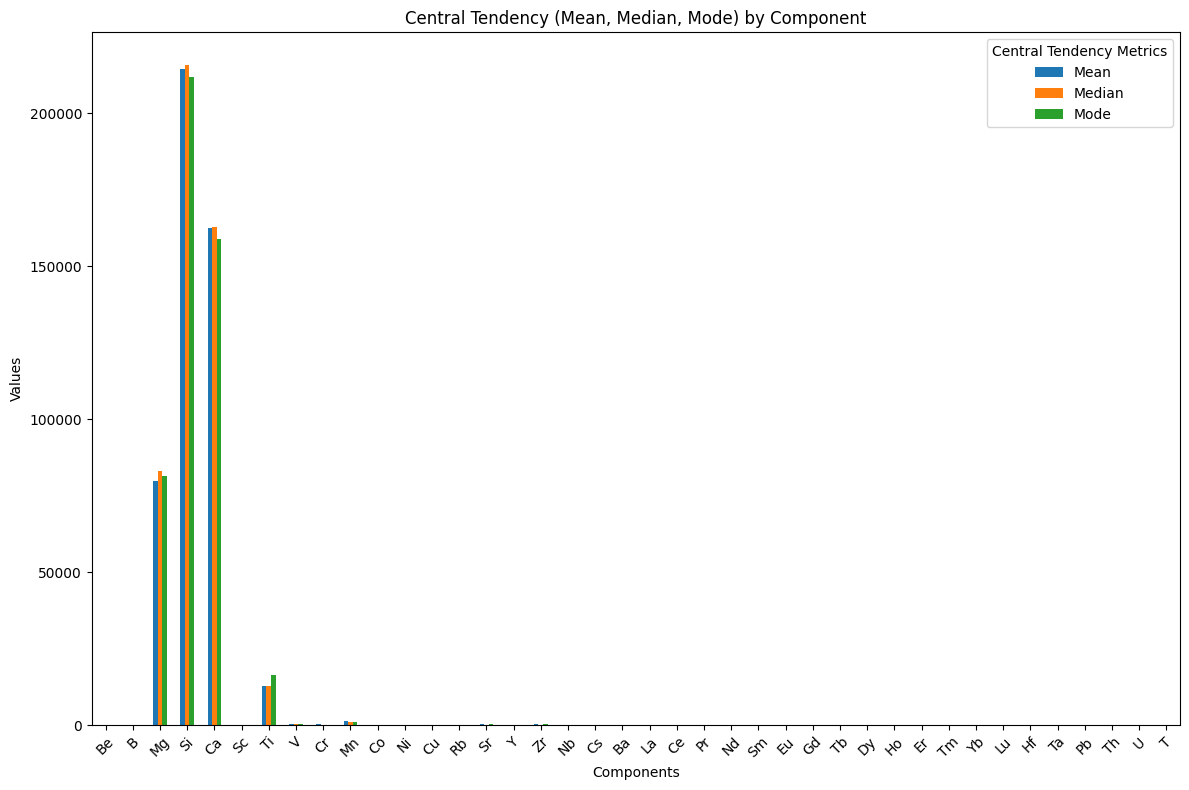

In [ ]:
#for the mean, median, and standard deviation for numeric columns (e.g., element concentrations)

import pandas as pd

# Calculate mean, median, and mode for each column
central_tendency = pd.DataFrame({
    'Mean': laicpms_no_sample.mean(),
    'Median': laicpms_no_sample.median(),
    'Mode': laicpms_no_sample.mode().iloc[0]
})

# Display the results
central_tendency

# Visualization: Grouped Bar Chart for Mean, Median, and Mode
plt.figure(figsize=(12, 8))

# Generate bar chart
central_tendency.plot(kind='bar', figsize=(12, 8), alpha=1.0)

# Customize the plot
plt.title('Central Tendency (Mean, Median, Mode) by Component')
plt.ylabel('Values')
plt.xlabel('Components')
plt.xticks(rotation=45)
plt.legend(title='Central Tendency Metrics')
plt.tight_layout()

# Show the plot
plt.show()

To find the range of elements

In [ ]:
laicpms_with_age.columns

Index(['SAMPLE', 'Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn',
       'Co', 'Ni', 'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce',
       'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu',
       'Hf', 'Ta', 'Pb', 'Th', 'U', 'T'],
      dtype='object')

In [ ]:
import pandas as pd


# Calculate the range of values for the major oxides
elements = ['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn',
       'Co', 'Ni', 'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce',
       'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu',
       'Hf', 'Ta', 'Pb', 'Th', 'U', 'T']
ranges = laicpms_with_age[elements].agg(['min', 'max'])

# Print the range of values
print("Range of values for the major oxides:")
print(ranges)
ranges.T

Range of values for the major oxides:
        Be     B         Mg         Si         Ca      Sc        Ti       V  \
min  0.084  2.13   40221.94  179021.16  155365.61    8.69   6179.49  157.31   
max  3.040  4.36  127362.22  264361.25  170710.56  114.69  22218.04  513.20   

          Cr       Mn  ...     Er     Tm     Yb      Lu     Hf      Ta     Pb  \
min     1.27   610.04  ...  0.905  0.131  0.661  0.0837   1.47  0.0808  0.021   
max  3515.03  3578.18  ...  4.610  0.588  4.010  0.6380  13.75  5.1800  4.000   

         Th       U    T  
min  0.0264  0.0083  1.0  
max  3.4400  0.7200  3.0  

[2 rows x 40 columns]


,min,max
Be,0.0840,3.040
B,2.1300,4.360
Mg,40221.9400,127362.220
Si,179021.1600,264361.250
Ca,155365.6100,170710.560
Sc,8.6900,114.690
Ti,6179.4900,22218.040
V,157.3100,513.200
Cr,1.2700,3515.030
Mn,610.0400,3578.180


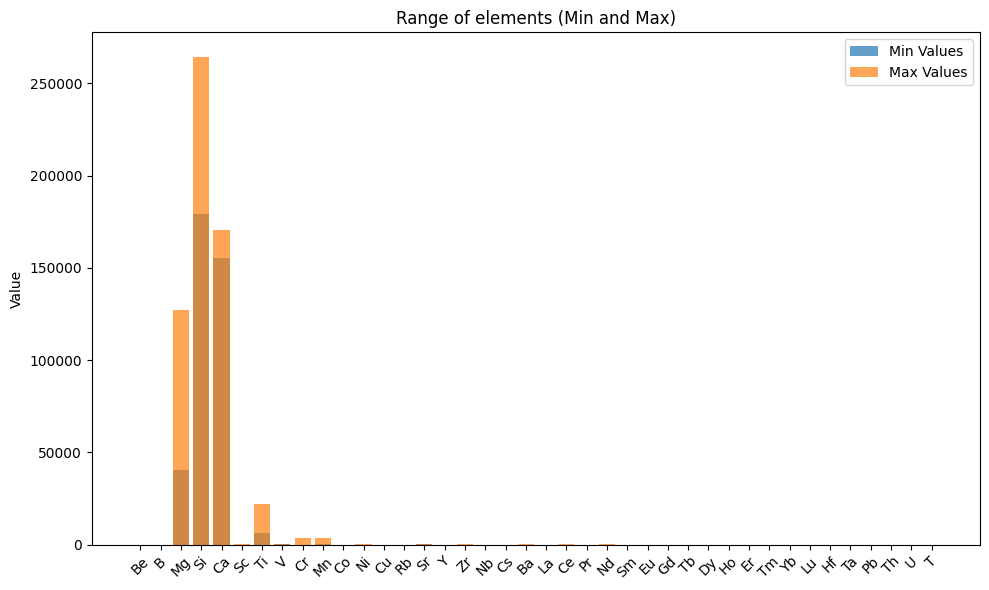

In [ ]:
# Visualization: Bar chart for min and max values
plt.figure(figsize=(10, 6))
x_labels = ranges.columns
min_values = ranges.loc['min']
max_values = ranges.loc['max']

# Plot min values
plt.bar(x_labels, min_values, alpha=0.7, label='Min Values')
# Plot max values
plt.bar(x_labels, max_values, alpha=0.7, label='Max Values')

# Add labels, title, and legend
plt.ylabel('Value')
plt.title('Range of elements (Min and Max)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

**Are there any columns with highly skewed distributions?**

In [43]:
laicpms_no_sample.columns

Index(['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Co', 'Ni',
       'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U', 'T'],
      dtype='object')

In [48]:
laicpms_transpose = laicpms_no_sample.describe().T

laicpms_transpose

,count,mean,std,min,25%,50%,75%,max
Be,118.0,0.752390,0.617563,0.0840,0.32000,0.54000,0.96750,3.040
B,118.0,3.114576,0.462889,2.1300,2.79250,3.01500,3.43500,4.360
Mg,118.0,79823.363390,16489.581648,40221.9400,70831.61750,83047.53500,91774.19250,127362.220
Si,118.0,214703.390678,13646.538301,179021.1600,205014.49750,215747.95500,223623.41000,264361.250
Ca,118.0,162694.390678,2280.958473,155365.6100,161437.12500,162767.25000,164036.61250,170710.560
Sc,118.0,59.421864,26.139184,8.6900,40.07000,67.09000,75.63250,114.690
Ti,118.0,12896.465763,3126.560776,6179.4900,10466.73500,12621.97000,15246.82500,22218.040
V,118.0,330.366356,61.406780,157.3100,288.86000,320.49000,367.01500,513.200
Cr,118.0,496.419576,813.541150,1.2700,11.01000,143.75000,529.99750,3515.030
Mn,118.0,1253.912797,612.230046,610.0400,842.44750,1029.26500,1489.51750,3578.180


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables in the dataset
variables = laicpms_no_sample[['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Mn', 'Co', 'Ni']]                #.columns

# Calculate the number of rows needed dynamically
n_variables = len(variables)
n_cols = 3  # Fixed number of columns
n_rows = (n_variables + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots
plt.figure(figsize=(15, n_rows * 4))  # Adjust height dynamically
for i, var in enumerate(variables, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(laicpms_no_sample[var], kde=True, bins=10, color='blue', label=var)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()


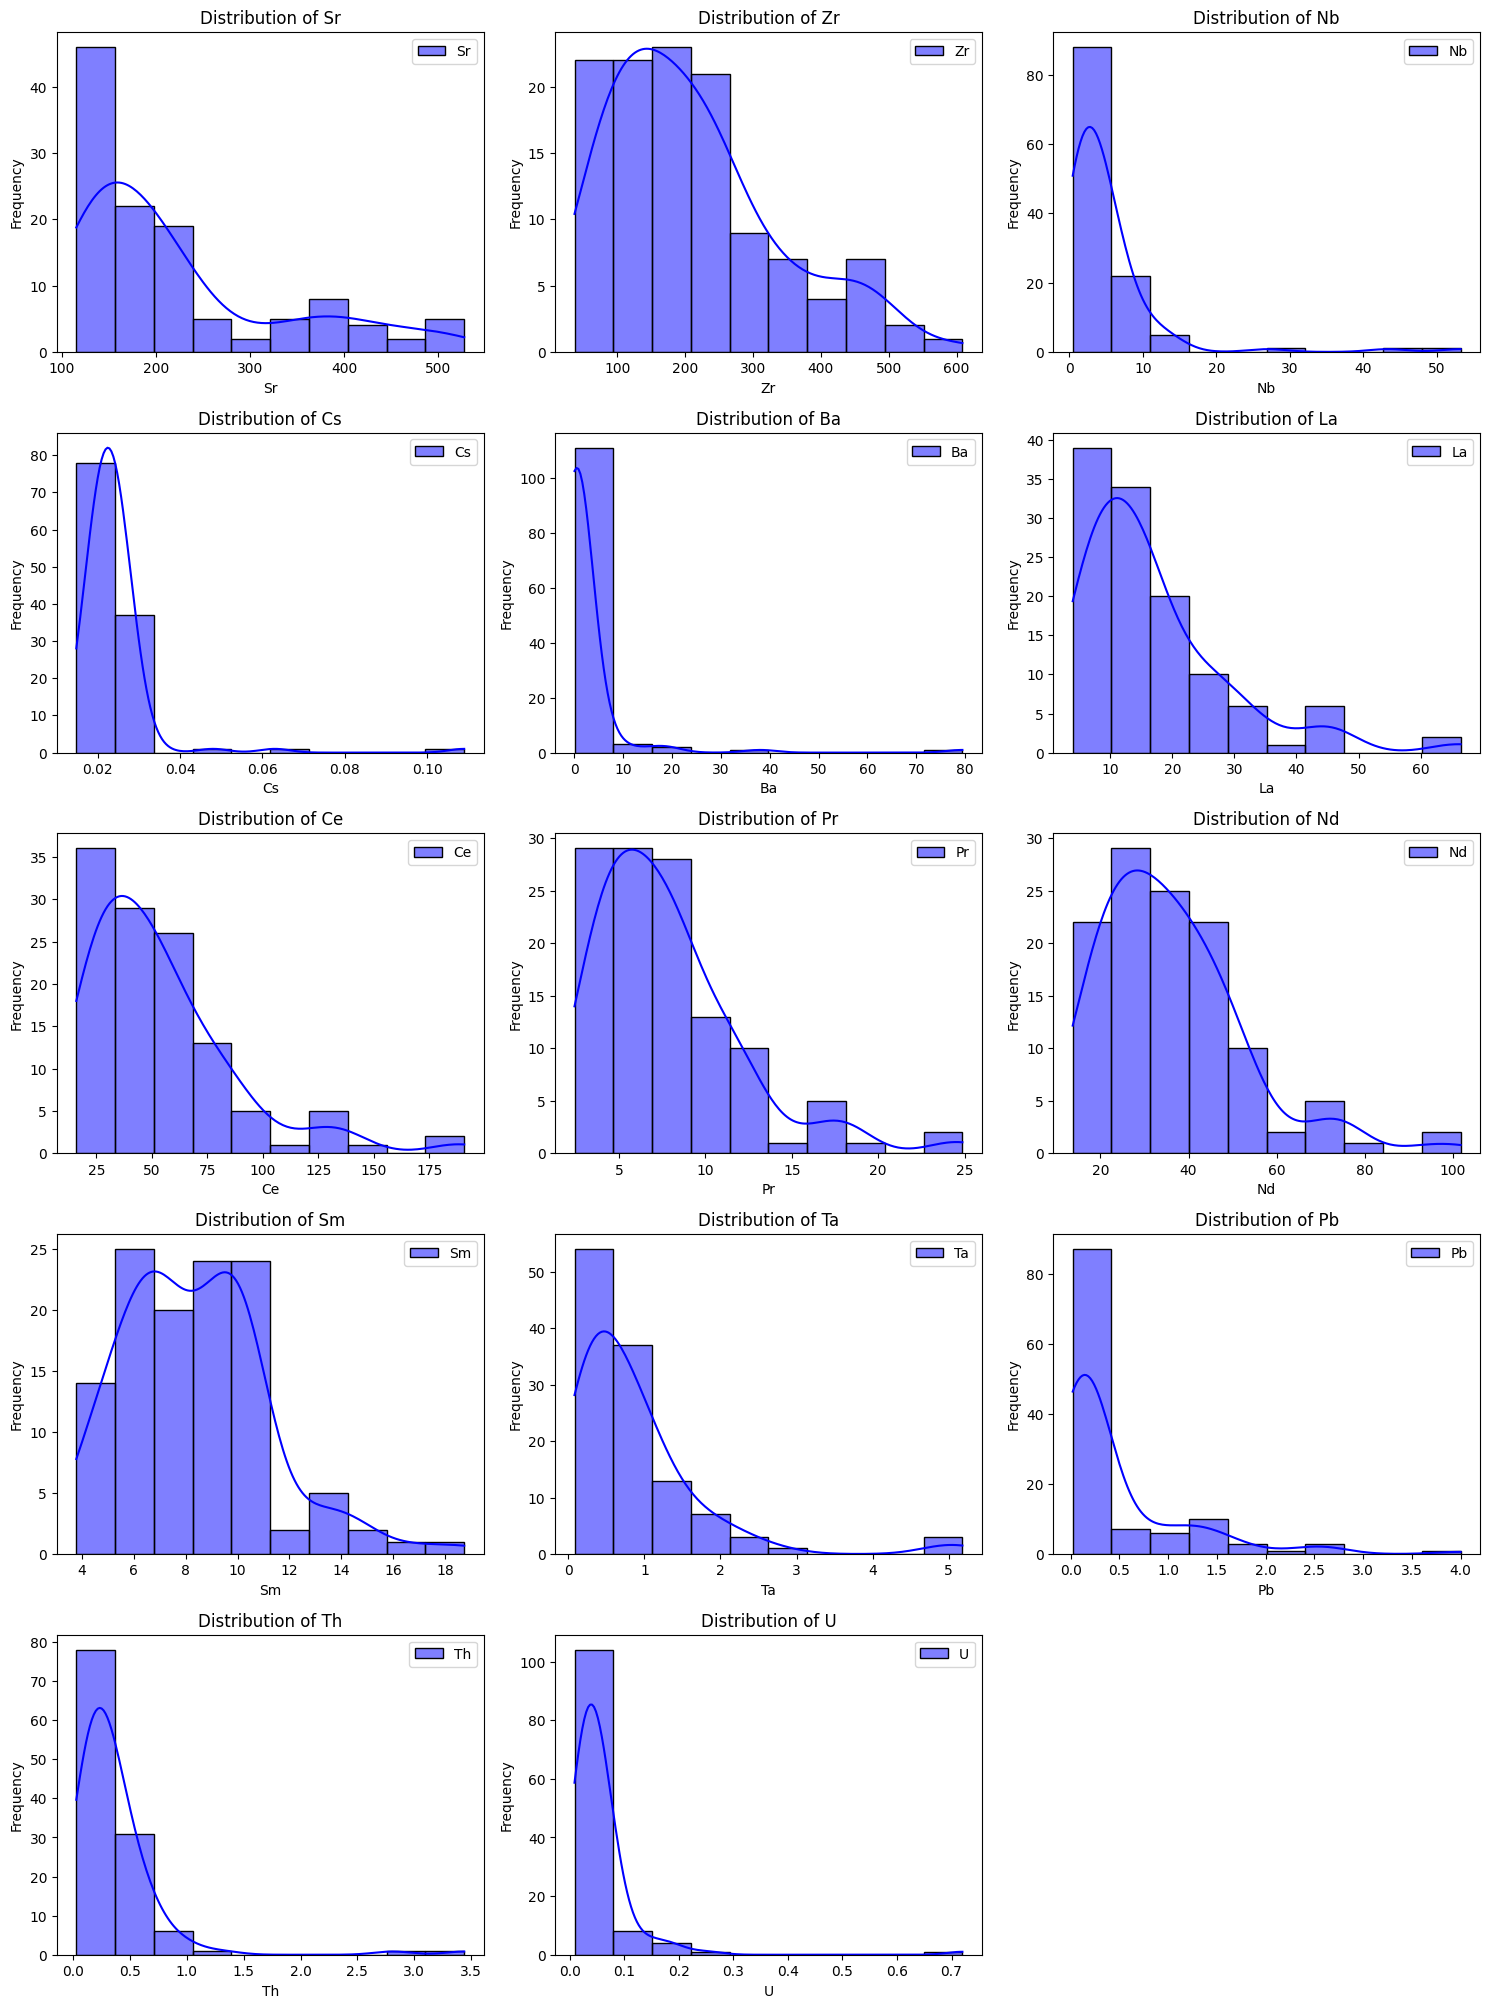

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables in the dataset
variables = laicpms_no_sample[['Sr', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm',  'Ta',
       'Pb', 'Th', 'U']]                #.columns

# Calculate the number of rows needed dynamically
n_variables = len(variables)
n_cols = 3  # Fixed number of columns
n_rows = (n_variables + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots
plt.figure(figsize=(15, n_rows * 4))  # Adjust height dynamically
for i, var in enumerate(variables, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(laicpms_no_sample[var], kde=True, bins=10, color='blue', label=var)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
laicpms_no_sample.columns

Index(['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Co', 'Ni',
       'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U', 'T'],
      dtype='object')

In [ ]:
laicpms_no_sample.columns

Index(['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Co', 'Ni',
       'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U', 'T'],
      dtype='object')

#**Relationships and Correlations**

•	Are there strong correlations between certain element concentrations (e.g., Si and Ca, Sr and Ba)?

•	How do related elements (e.g., rare earth elements like La, Ce, Nd) compare in terms of their distributions?


correlation chart

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix to assess covariation
correlation_matrix = laicpms_no_sample.corr()

# Generate a heatmap for visualizing the covariation
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap of Correlation Between Chemical Components")
plt.show()


In [ ]:
# Calculate the Pearson correlation matrix
pearson_correlation = laicpms_no_sample.corr(method='pearson')

# Calculate the Spearman correlation matrix
spearman_correlation = laicpms_no_sample.corr(method='spearman')

# Display the results for key elements
key_elements = ['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Co', 'Ni',
       'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U', 'T']

pearson_corr_selected = pearson_correlation.loc[key_elements, key_elements]

spearman_corr_selected = spearman_correlation.loc[key_elements, key_elements]

# Display the Pearson and Spearman correlation matrices to the user
print("Pearson Correlation Matrix for Key elemts", pearson_corr_selected)

print("Spearman Correlation Matrix for Key elements", spearman_corr_selected)

In [ ]:
# Visualization: Heatmaps for Pearson and Spearman Correlation
plt.figure(figsize=(20, 18))
sns.heatmap(pearson_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Pearson Correlation Matrix (key_elements)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 18))
sns.heatmap(spearman_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Spearman Correlation Matrix (key_elements)")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the Pearson correlation matrix
pearson_correlation = laicpms_no_sample.corr(method='pearson')

# Calculate the Spearman correlation matrix
spearman_correlation = laicpms_no_sample.corr(method='spearman')

# Display the results for key elements
key_elements = [ 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U', 'T']

pearson_corr_selected = pearson_correlation.loc[key_elements, key_elements]

spearman_corr_selected = spearman_correlation.loc[key_elements, key_elements]

# Display the Pearson and Spearman correlation matrices to the user
print("Pearson Correlation Matrix for Key elemts", pearson_corr_selected)

print("Spearman Correlation Matrix for Key elements", spearman_corr_selected)

# Visualization: Heatmaps for Pearson and Spearman Correlation
plt.figure(figsize=(20, 18))
sns.heatmap(pearson_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Pearson Correlation Matrix (key_elements)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 18))
sns.heatmap(spearman_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Spearman Correlation Matrix (key_elements)")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the Pearson correlation matrix
pearson_correlation = laicpms_no_sample.corr(method='pearson')

# Calculate the Spearman correlation matrix
spearman_correlation = laicpms_no_sample.corr(method='spearman')

# Display the results for key elements
key_elements = [ 'Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Co', 'Ni',
       'Cu', 'Rb',  'T']

pearson_corr_selected = pearson_correlation.loc[key_elements, key_elements]

spearman_corr_selected = spearman_correlation.loc[key_elements, key_elements]

# Display the Pearson and Spearman correlation matrices to the user
print("Pearson Correlation Matrix for Key elemts", pearson_corr_selected)

print("Spearman Correlation Matrix for Key elements", spearman_corr_selected)

# Visualization: Heatmaps for Pearson and Spearman Correlation
plt.figure(figsize=(20, 18))
sns.heatmap(pearson_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Pearson Correlation Matrix (key_elements)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 18))
sns.heatmap(spearman_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Spearman Correlation Matrix (key_elements)")
plt.tight_layout()
plt.show()

#**scatter plot**

In [ ]:
laicpms_no_sample.columns

Index(['Be', 'B', 'Mg', 'Si', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Co', 'Ni',
       'Cu', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U', 'T'],
      dtype='object')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select subset of data if the dataset is too large
data = laicpms_no_sample[['Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U']].sample(500, random_state=42) if len(laicpms_no_sample) > 500 else laicpms_no_sample[['Sr', 'Y', 'Zr', 'Nb', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
       'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta',
       'Pb', 'Th', 'U']]

# Customizing pairplot with specific styles and reducing computation
g = sns.PairGrid(data, diag_sharey=False)
g.map_upper(sns.scatterplot, alpha=0.5)  # Scatter plots in the upper triangle
g.map_diag(sns.histplot, kde=True)      # Histograms on the diagonal
g.map_lower(sns.kdeplot, fill=True)     # Density plots in the lower triangle
g.fig.suptitle("Pairwise Scatterplots with Reduced Load", y=1.02)

plt.show()


Output hidden; open in https://colab.research.google.com to view.

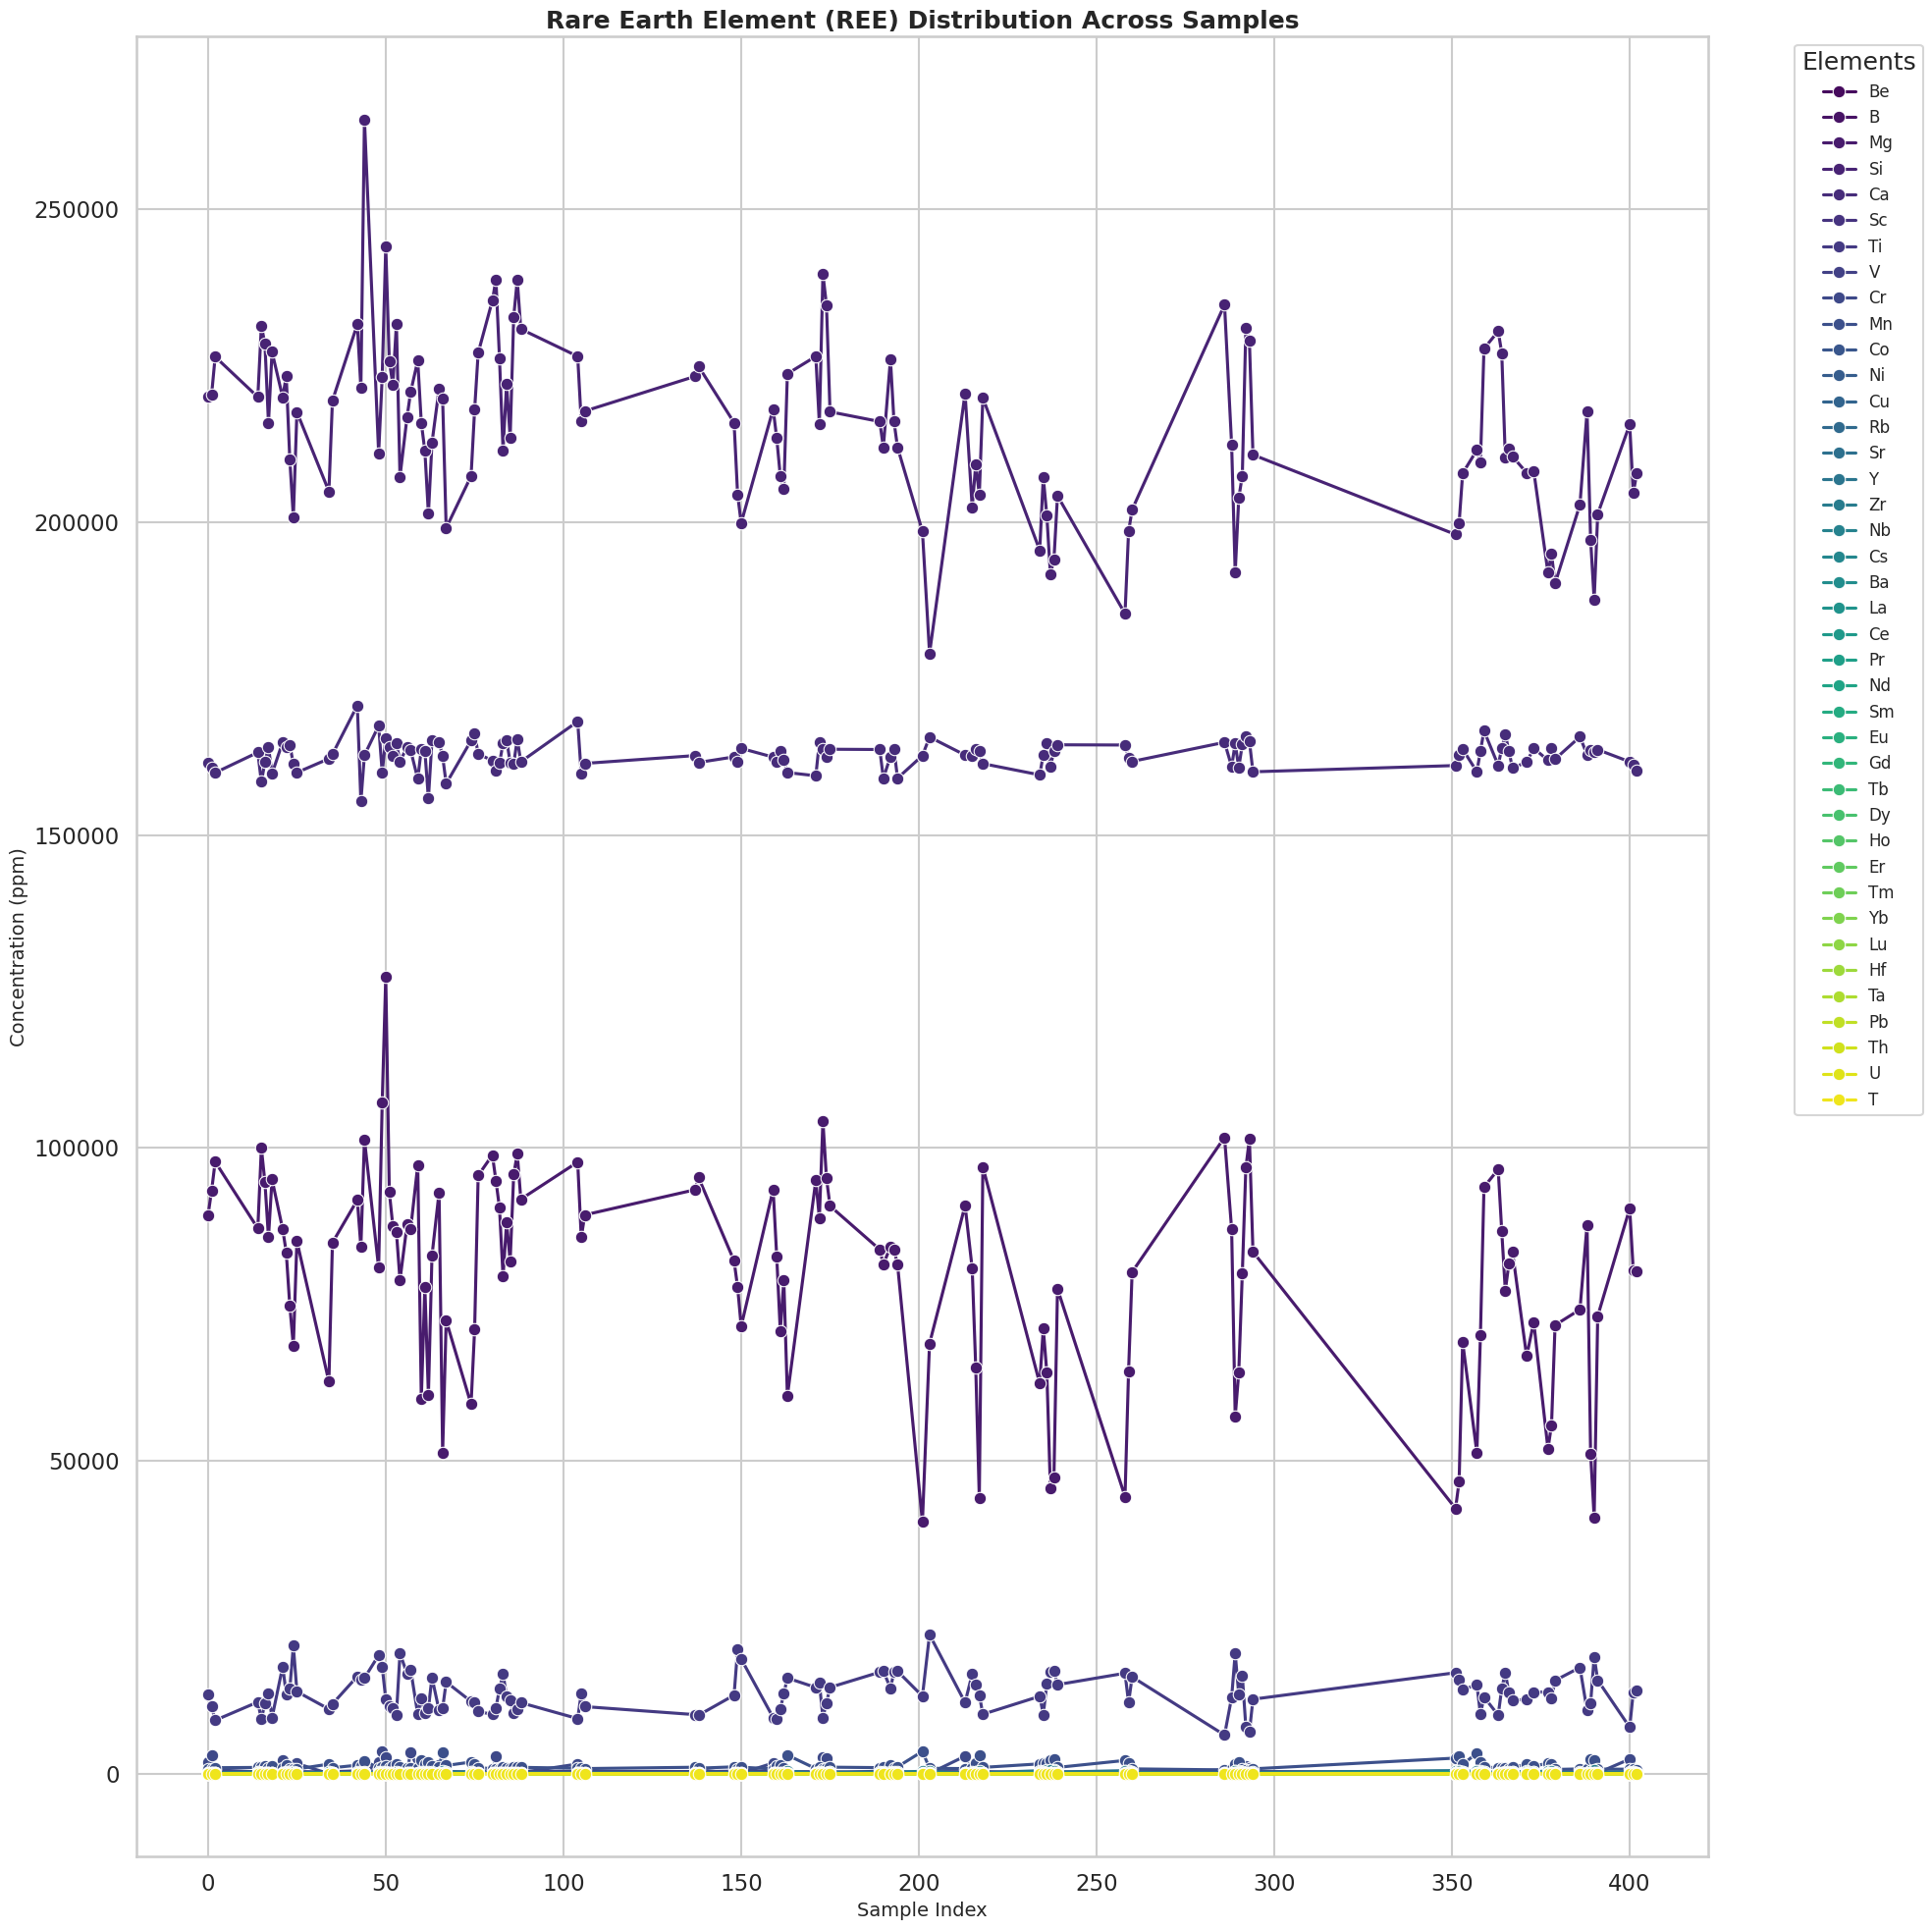

In [ ]:
import seaborn as sns

# Set a seaborn style for better aesthetics
sns.set(style="whitegrid", context="talk")

# Create a long-form dataframe for seaborn
ree_data_long = laicpms_no_sample.reset_index().melt(
    id_vars=["index"], var_name="Element", value_name="Concentration"
)

# Plotting REE trends using seaborn
plt.figure(figsize=(20, 20))
sns.lineplot(
    data=ree_data_long,
    x="index",
    y="Concentration",
    hue="Element",
    marker="o",
    palette="viridis"
)

# Enhancing the plot
plt.title("Rare Earth Element (REE) Distribution Across Samples", fontsize=18, weight='bold')
plt.xlabel("Sample Index", fontsize=14)
plt.ylabel("Concentration (ppm)", fontsize=14)
plt.legend(title="Elements", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Checking for potential grouping categories in the dataset
grouping_columns =['T']  # Columns that might represent categories

# Inspect the unique values in these columns to confirm their use as grouping categories
grouping_info = {col: laicpms_no_sample[col].unique() for col in grouping_columns}

grouping_info


{'T': array([3., 1., 2.])}

<ipython-input-35-3542790a2189>:35: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the m

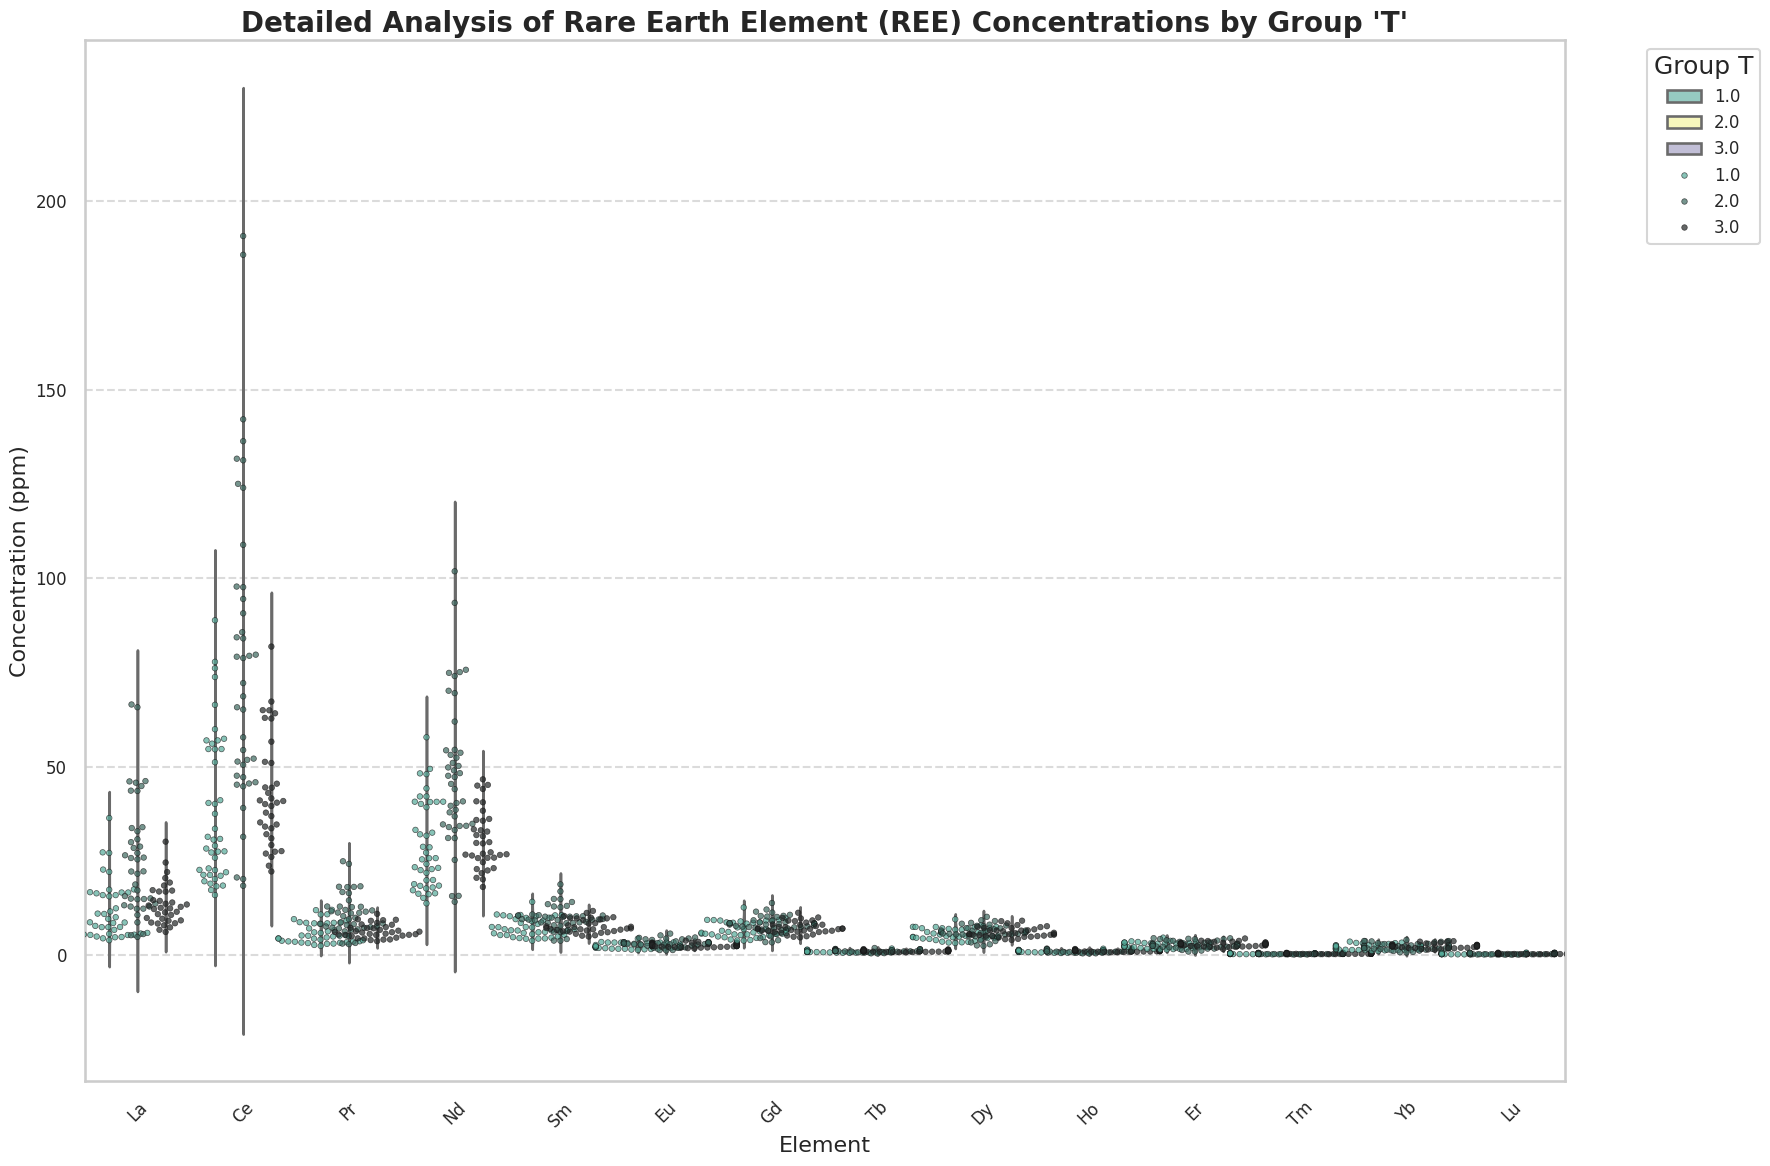

In [ ]:
# Filter columns corresponding to rare earth elements (REEs)
ree_columns = [
    'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb',
    'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'
]



# Grouped analysis for REE concentrations by category 'T' (as it has multiple groups)
ree_data_with_groups = laicpms_no_sample[ree_columns + ['T']].dropna()
ree_data_with_groups[ree_columns] = ree_data_with_groups[ree_columns].apply(pd.to_numeric, errors='coerce')

# Create a long-form dataframe for grouped analysis
ree_grouped_long = ree_data_with_groups.melt(
    id_vars=['T'], var_name="Element", value_name="Concentration"
)


# Enhanced visualization for grouped REE concentrations by 'T' without splitting

plt.figure(figsize=(18, 12))

# Create a violin plot for detailed distribution visualization
sns.violinplot(
    data=ree_grouped_long,
    x="Element",
    y="Concentration",
    hue="T",
    inner="quartile",
    palette="Set3",
    dodge=True
)

# Overlay swarmplot for individual data points visualization
sns.swarmplot(
    data=ree_grouped_long,
    x="Element",
    y="Concentration",
    hue="T",
    dodge=True,
    palette="dark:#5A9_r",
    alpha=0.7,
    size=4,
    edgecolor="gray",
    linewidth=0.5
)

# Enhancing the plot aesthetics
plt.title("Detailed Analysis of Rare Earth Element (REE) Concentrations by Group 'T'", fontsize=20, weight='bold')
plt.xlabel("Element", fontsize=16)
plt.ylabel("Concentration (ppm)", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Group T", fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
icpms

In [ ]:
icpms.isna().sum()

In [ ]:
icpms.dtypes

In [ ]:
laicpms_no_sample.dtypes

In [ ]:
icpms2 = laicpms_no_sample

In [ ]:
icpms2.to_excel("/content/icpms3.xlsx", sheet_name="icpms", index= False)

icpms3 = pd.read_excel('/content/icpms3.xlsx',
                       sheet_name="icpms")

In [ ]:
# importing necessary libraries and reloading the file due to the reset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Separate features and target if the target column is known (assuming it's 'T')
features = icpms3.drop(columns=['T'], errors='ignore')  # Drop the target column if it exists
target = icpms3['T'] if 'T' in icpms3.columns else None

# Apply Min-Max Scaling
scaler = MinMaxScaler(feature_range=(0, 1),
                      clip=True,
                      copy=False)
scaled_features = scaler.fit_transform(features)

# Convert the scaled data back into a DataFrame

scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns)

# If target exists, append it back to the scaled features
if target is not None:
    scaled_features_df['T'] = target

scaled_features_df


,Be,B,Mg,Si,Ca,Sc,Ti,V,Cr,Mn,...,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U,T
0,0.076455,0.331839,0.562979,0.481011,0.406252,0.806038,0.408197,0.574503,0.510709,0.060068,...,0.365722,0.284464,0.253509,0.188165,0.184853,0.024945,0.004272,0.020389,0.013067,3
1,0.066306,0.358744,0.607880,0.484989,0.356230,0.799434,0.287865,0.434741,0.845283,0.055321,...,0.176788,0.153173,0.223649,0.180949,0.127036,0.030828,0.008294,0.022440,0.010398,3
2,0.024019,0.318386,0.660698,0.555511,0.299300,0.797830,0.147122,0.280368,0.175336,0.118970,...,0.317139,0.225383,0.292326,0.254916,0.213355,0.021023,0.009801,0.025369,0.007306,3
3,0.164411,0.372197,0.538465,0.480183,0.510926,0.643019,0.329161,0.513445,0.086343,0.134094,...,0.403509,0.452954,0.355031,0.348728,0.498371,0.088681,0.058306,0.057007,0.053253,3
4,0.012179,0.219731,0.685907,0.613500,0.203947,0.849151,0.156634,0.286409,0.250302,0.131429,...,0.411606,0.385120,0.322186,0.372181,0.263029,0.036908,0.018095,0.042653,0.026837,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,0.810555,0.318386,0.008094,0.100615,0.511231,0.027075,0.781174,0.609065,0.000014,0.506964,...,0.892038,0.975930,1.000000,0.926033,0.942997,1.000000,0.066097,0.204359,0.090909,2
114,0.161028,0.327354,0.377763,0.261107,0.539476,0.535755,0.546824,0.385625,0.034769,0.043617,...,0.395412,0.321663,0.349059,0.235071,0.342834,0.100643,0.027645,0.068432,0.032457,2
115,0.100135,0.300448,0.574967,0.428766,0.413400,0.498962,0.077566,0.137992,0.665748,0.038320,...,0.112011,0.072210,0.122126,0.085333,0.080619,0.040242,0.037447,0.067260,0.039061,2
116,0.198241,0.242152,0.461683,0.300967,0.381247,0.442547,0.425420,0.186237,0.049281,0.047504,...,0.419703,0.396061,0.307256,0.310843,0.324104,0.113194,0.045991,0.106222,0.066180,2


In [ ]:
icpms1 = scaled_features_df

icpms1

icpms1.to_excel('/content/icpms(1).xlsx',sheet_name='icpms', index=False)

In [ ]:
icpms1a = pd.read_excel('/content/icpms(1).xlsx', sheet_name='icpms')

icpms1a